Train balanceado — Legítimas: 14400 | Fraudes: 14400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/60
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9774 - auc: 0.9981 - loss: 0.0689 - precision: 0.9702 - recall: 0.9696 - val_accuracy: 0.9981 - val_auc: 0.0000e+00 - val_loss: 0.0045 - val_precision: 1.0000 - val_recall: 0.9981
Epoch 2/60
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9993 - auc: 1.0000 - loss: 0.0035 - precision: 0.9998 - recall: 0.9985 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 3.9342e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/60
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0018 - precision: 0.9998 - recall: 0.9994 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 6.0423e-05 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/60
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0013 - precision: 0.9995 - recall: 0.9995 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 5.3506e-05 - val_precision: 1.0000 - val_recall: 1.0000
Epoc

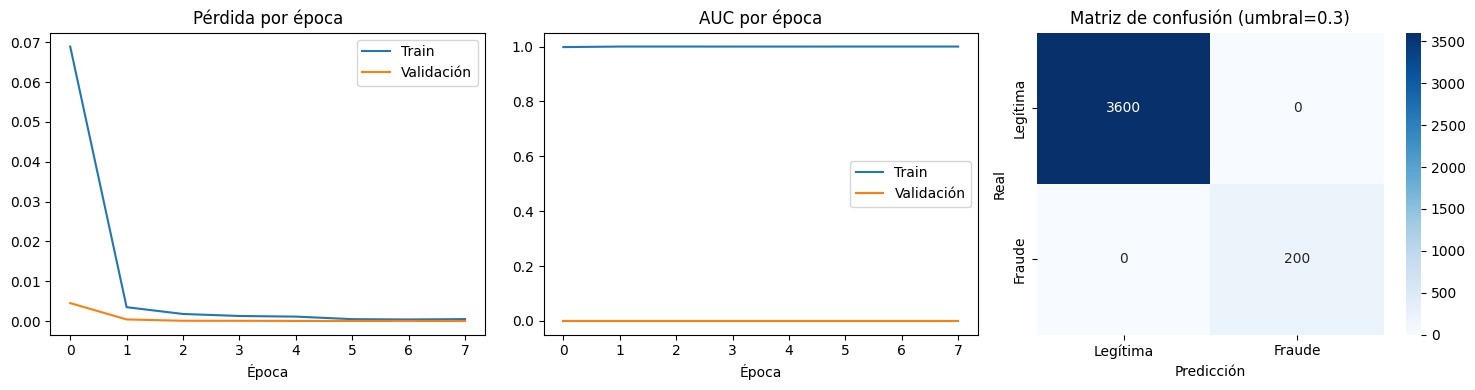


✓ Entrenamiento completo — todos los archivos guardados en Drive


In [ ]:
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import logging

log = logging.getLogger("pipeline_fraude")

CARPETA = '/content/drive/MyDrive/Colab Notebooks/Gestion_Datos_IA_EV2'
df_clean = pd.read_csv(f'{CARPETA}/datos_limpios.csv')
log.info(f"Dataset cargado para entrenamiento: {df_clean.shape}")

FEATURES = [
    'amt', 'hour', 'is_night', 'geo_distance',
    'amt_zscore', 'city_pop', 'category_enc',
    'gender_enc', 'lat', 'merch_lat', 'merch_long'
]
TARGET = 'is_fraud'

# --- 4.1 Split train/test ---
X = df_clean[FEATURES].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
log.info(f"Train: {X_train.shape} | Test: {X_test.shape}")

# --- 4.2 Escalar ---
# Importante: fit SOLO en train, transform en ambos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
log.info("Escalado completado")

# --- 4.3 SMOTE: balancear clases solo en train ---
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

conteo = dict(zip(*np.unique(y_train_bal, return_counts=True)))
log.info(f"Después de SMOTE: {conteo}")
print(f"Train balanceado — Legítimas: {conteo[0]} | Fraudes: {conteo[1]}")

# --- 4.4 Definir arquitectura ---
tf.random.set_seed(42)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_bal.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# --- 4.5 Entrenar ---
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        f'{CARPETA}/mejor_modelo.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=0
    )
]

history = model.fit(
    X_train_bal, y_train_bal,
    epochs=60,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

log.info(f"Entrenamiento terminado en época {len(history.history['loss'])}")

# --- 4.6 Elegir umbral óptimo ---
y_prob = model.predict(X_test).flatten()

print("\n=== Análisis de umbrales ===")
print(f"{'Umbral':<10} {'F1':>8} {'Recall fraude':>15} {'Precisión fraude':>18}")
print("-" * 55)

mejores = {}
for umbral in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred  = (y_prob >= umbral).astype(int)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    recall  = y_pred[y_test==1].mean() if y_test.sum() > 0 else 0
    prec    = y_pred[y_pred==1].size and (y_test[y_pred==1].mean() if y_pred.sum() > 0 else 0)
    mejores[umbral] = f1
    print(f"{umbral:<10.2f} {f1:>8.3f} {recall:>15.3f} {prec:>18.3f}")

UMBRAL = max(mejores, key=mejores.get)
print(f"\nUmbral óptimo seleccionado: {UMBRAL}")
log.info(f"Umbral óptimo: {UMBRAL}")

# --- 4.7 Evaluación final ---
y_pred_final = (y_prob >= UMBRAL).astype(int)
auc          = roc_auc_score(y_test, y_prob)
f1_final     = f1_score(y_test, y_pred_final)

print(f"\n=== Métricas finales (umbral = {UMBRAL}) ===")
print(classification_report(y_test, y_pred_final,
                             target_names=['Legítima','Fraude']))
log.info(f"AUC-ROC: {auc:.4f} | F1: {f1_final:.4f}")

# --- 4.8 Gráficas ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validación')
axes[0].set_title('Pérdida por época')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history.history['auc'],      label='Train')
axes[1].plot(history.history['val_auc'],  label='Validación')
axes[1].set_title('AUC por época')
axes[1].set_xlabel('Época')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Legítima','Fraude'],
            yticklabels=['Legítima','Fraude'])
axes[2].set_title(f'Matriz de confusión (umbral={UMBRAL})')
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Predicción')

plt.tight_layout()
plt.savefig(f'{CARPETA}/resultados_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
log.info("Gráficas guardadas")

# --- 4.9 Guardar modelo y artefactos en Drive ---
import json

model.save(f'{CARPETA}/modelo_fraude_final.keras')

with open(f'{CARPETA}/scaler_fraude.pkl', 'wb') as f:
    pickle.dump(scaler, f)

metricas = {
    'auc_roc'   : round(float(auc), 4),
    'f1_fraude' : round(float(f1_final), 4),
    'umbral'    : UMBRAL,
    'epocas'    : len(history.history['loss']),
    'features'  : FEATURES
}
with open(f'{CARPETA}/metricas_modelo.json', 'w') as f:
    json.dump(metricas, f, indent=2)

log.info(f"Modelo guardado — métricas: {metricas}")
print("\n✓ Entrenamiento completo — todos los archivos guardados en Drive")